Analyse des données

IMPORTATION

In [ ]:
import torch
import json
import os
import matplotlib.pyplot as plt
from PIL import Image

analyse t2i et i2t : 

In [1]:
import torch
import json
import os
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_IMG_DIR = "../mSigLIP-CLoRA/VN3K/imgs/"
RANKINGS_FILE = "mes_erreurs_t2i_i2t.pt" # fichier log fin entrainement
JSON_FILE = "../mSigLIP-CLoRA/VN3K/data_captions_vn3k.json" 

print("Chargement des données...")

# ---------------------------------------------------------
# /!\ À DÉCOMMENTER 
# rankings_data = torch.load(RANKINGS_FILE)
# t2i_ranking = rankings_data["t2i"]
# i2t_ranking = rankings_data["i2t"]
# ---------------------------------------------------------

# Chargement du JSON
with open(JSON_FILE, "r", encoding="utf-8") as f:
    dataset_liste = json.load(f)

# Astuce : On transforme la liste en dictionnaire basé sur "id" pour chercher plus vite
dataset_info = {item["id"]: item for item in dataset_liste}

def get_person_id(file_path):
    """Extrait 'Person1.2' à partir de 'TEST_DATA/Person1.2/output_2.jpg'"""
    return file_path.split('/')[1]

# ==========================================
# 2. FONCTION T2I (Texte vers Image)
# ==========================================
def inspecter_requete_t2i(text_id, dictionnaire_ranking, dataset_info, top_k=5):
    vrai_item = dataset_info[text_id]
    texte_requete = vrai_item["captions"][0] # On prend la première phrase de la liste
    vraie_personne_id = get_person_id(vrai_item["file_path"])
    
    images_predites_ids = dictionnaire_ranking[text_id][:top_k]
    
    fig, axes = plt.subplots(1, top_k, figsize=(15, 4))
    fig.suptitle(f"Requête: {texte_requete}\n(Cherche: {vraie_personne_id})", fontsize=12, fontweight="bold", y=1.05)
    
    for i, img_id in enumerate(images_predites_ids):
        item_predit = dataset_info[img_id]
        chemin_complet = os.path.join(BASE_IMG_DIR, item_predit["file_path"])
        personne_predite_id = get_person_id(item_predit["file_path"])
        
        ax = axes[i]
        try:
            img = Image.open(chemin_complet)
            ax.imshow(img)
            
            est_correct = (personne_predite_id == vraie_personne_id)
            couleur = "green" if est_correct else "red"
            titre = "Vrai" if est_correct else f"Faux ({personne_predite_id})"
            
            ax.set_title(f"Rang {i+1} - {titre}", color=couleur, fontweight="bold", fontsize=10)
        except FileNotFoundError:
            ax.set_title("Image introuvable")
            
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. FONCTION I2T (Image vers Texte)
# ==========================================
def inspecter_requete_i2t(image_id, dictionnaire_ranking, dataset_info, top_k=5):
    vrai_item = dataset_info[image_id]
    chemin_complet = os.path.join(BASE_IMG_DIR, vrai_item["file_path"])
    vraie_personne_id = get_person_id(vrai_item["file_path"])
    
    # Affichage de l'image
    try:
        img = Image.open(chemin_complet)
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"Image Requête ({vraie_personne_id})", fontweight="bold")
        plt.axis("off")
        plt.show()
    except FileNotFoundError:
        print("Image requête introuvable.")
        return

    # Affichage des textes
    textes_predits_ids = dictionnaire_ranking[image_id][:top_k]
    print(f"\n--- TOP {top_k} DES TEXTES TROUVÉS ---")
    
    for i, txt_id in enumerate(textes_predits_ids):
        item_predit = dataset_info[txt_id]
        texte_predit = item_predit["captions"][0]
        personne_predite_id = get_person_id(item_predit["file_path"])
        
        est_correct = (personne_predite_id == vraie_personne_id)
        symbole = "✅" if est_correct else "❌"
        
        print(f"{i+1}. {symbole} [{personne_predite_id}] : {texte_predit}")



Chargement des données...


Visualisation de la circle loss

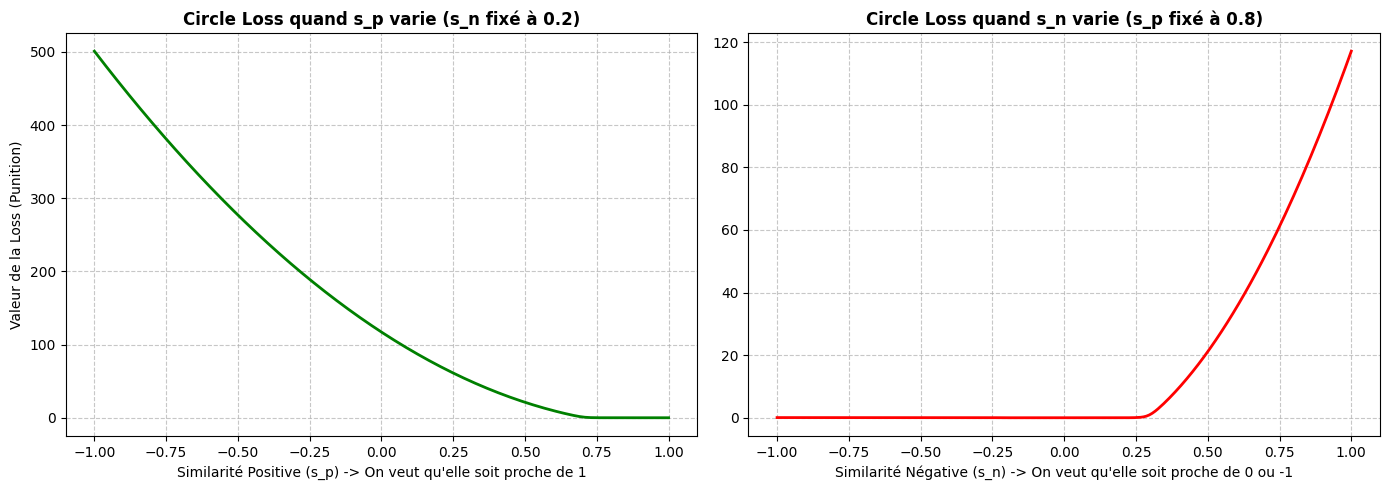

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# On recrée les maths de ta fonction de manière simplifiée pour un seul cas (1 positif, 1 négatif)
def simulated_circle_loss(s_p, s_n, m=0.25, gamma=128):
    # Les poids dynamiques (alpha)
    alpha_p = np.maximum(0, 1 + m - s_p)
    alpha_n = np.maximum(0, s_n + m)
    
    # Les marges (delta)
    delta_p = 1 - m
    delta_n = m
    
    # Les logits
    logit_p = -gamma * alpha_p * (s_p - delta_p)
    logit_n = gamma * alpha_n * (s_n - delta_n)
    
    # Calcul de la loss (simplifié avec log1p pour éviter les erreurs mathématiques extrêmes)
    # L = log(1 + exp(logit_p) * exp(logit_n))
    loss = np.log1p(np.exp(logit_p + logit_n))
    return loss

# --- SCÉNARIO 1 : Évolution de la Loss selon la similarité POSITIVE (s_p) ---
# On fixe le s_n (le négatif) à une valeur moyenne (ex: 0.2)
fixed_sn = 0.2
sp_values = np.linspace(-1, 1, 200) # 200 valeurs entre -1 et 1
loss_sp = [simulated_circle_loss(sp, fixed_sn) for sp in sp_values]

# --- SCÉNARIO 2 : Évolution de la Loss selon la similarité NÉGATIVE (s_n) ---
# On fixe le s_p (le positif) à une bonne valeur (ex: 0.8)
fixed_sp = 0.8
sn_values = np.linspace(-1, 1, 200)
loss_sn = [simulated_circle_loss(fixed_sp, sn) for sn in sn_values]

# --- AFFICHAGE GRAPHIQUE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1
ax1.plot(sp_values, loss_sp, color='green', linewidth=2)
ax1.set_title(f"Circle Loss quand s_p varie (s_n fixé à {fixed_sn})", fontweight="bold")
ax1.set_xlabel("Similarité Positive (s_p) -> On veut qu'elle soit proche de 1")
ax1.set_ylabel("Valeur de la Loss (Punition)")
ax1.grid(True, linestyle='--', alpha=0.7)

# Graphe 2
ax2.plot(sn_values, loss_sn, color='red', linewidth=2)
ax2.set_title(f"Circle Loss quand s_n varie (s_p fixé à {fixed_sp})", fontweight="bold")
ax2.set_xlabel("Similarité Négative (s_n) -> On veut qu'elle soit proche de 0 ou -1")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ANALYSE DU DATASET

--- RÉSULTATS DE L'ANALYSE ---
Nombre total d'identités uniques : 3000
Moyenne d'images par personne : 2.1
Maximum d'images pour une seule personne : 8
Minimum d'images pour une seule personne : 2
Longueur moyenne des textes : 28.9 mots


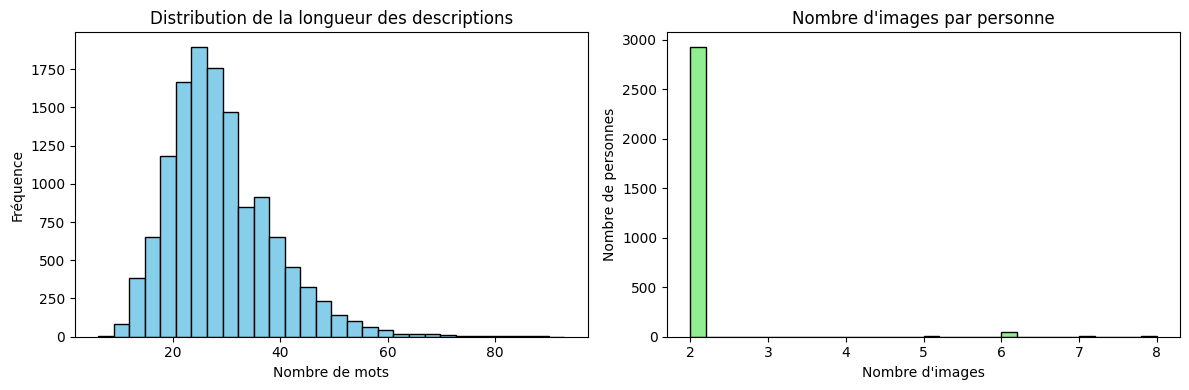

In [1]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Charger le fichier JSON
JSON_FILE = "../mSigLIP-CLoRA/VN3K/data_captions_vn3k.json"

with open(JSON_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

# Si ton JSON est une liste, on l'utilise directement. Si c'est un dico, adapte la clé.
# data = data["images"] # (Décommente si nécessaire)

text_lengths = []
person_identities = []

# 2. Extraire les données
for item in data:
    # Récupérer l'ID de la personne
    person_identities.append(item.get('id', 'inconnu'))
    
    # Récupérer les descriptions (parfois c'est une liste, parfois un texte simple)
    captions = item.get('captions', [])
    if isinstance(captions, str):
        captions = [captions]
        
    for cap in captions:
        # Compter le nombre de mots (en séparant par les espaces)
        text_lengths.append(len(cap.split()))

# 3. Calculer les statistiques
id_counts = Counter(person_identities)
images_per_person = list(id_counts.values())

print(f"--- RÉSULTATS DE L'ANALYSE ---")
print(f"Nombre total d'identités uniques : {len(id_counts)}")
print(f"Moyenne d'images par personne : {np.mean(images_per_person):.1f}")
print(f"Maximum d'images pour une seule personne : {np.max(images_per_person)}")
print(f"Minimum d'images pour une seule personne : {np.min(images_per_person)}")
print(f"Longueur moyenne des textes : {np.mean(text_lengths):.1f} mots")

# 4. Affichage des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graphique de gauche : Longueur des textes
ax1.hist(text_lengths, bins=30, color='skyblue', edgecolor='black')
ax1.set_title("Distribution de la longueur des descriptions")
ax1.set_xlabel("Nombre de mots")
ax1.set_ylabel("Fréquence")

# Graphique de droite : Images par personne
ax2.hist(images_per_person, bins=30, color='lightgreen', edgecolor='black')
ax2.set_title("Nombre d'images par personne")
ax2.set_xlabel("Nombre d'images")
ax2.set_ylabel("Nombre de personnes")

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# 1. Chemin vers le dossier des images
BASE_IMG_DIR = "../mSigLIP-CLoRA/VN3K/imgs/TRAINING_DATA"

# Prendre une image au hasard dans le dossier
all_images = [f for f in os.listdir(BASE_IMG_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_img_name = random.choice(all_images)
img_path = os.path.join(BASE_IMG_DIR, random_img_name)

# Charger l'image originale
original_img = Image.open(img_path).convert('RGB')

# 2. Définir les transformations (similaires à ton entraînement)
# On simule ce que PyTorch fait à tes images en coulisses
augmentations = T.Compose([
    T.Resize((224, 224)), # Taille standard pour SigLIP
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomHorizontalFlip(p=1.0), # On force le retournement pour l'exemple
    # T.RandomErasing() s'applique sur des Tenseurs, on le simule mentalement ici
])

# 3. Créer plusieurs versions augmentées
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Afficher l'originale
axes[0].imshow(original_img)
axes[0].set_title("Originale")
axes[0].axis('off')

# Afficher 3 variations
for i in range(1, 4):
    aug_img = augmentations(original_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmentation {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

IndexError: Cannot choose from an empty sequence